# Tilt Observer Results

This notebook discovers CSV files written by `evalTiltObserver`, loads the latest run by default, unwraps angle branches per dataset, and renders roll/pitch and gyroscope-bias estimates for every dataset.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_rows = 20

# Set RUN_DIR to a specific evalTiltObserver run directory to pin a run.
RUN_DIR = None # "/Users/dellaert/git/imuFactors/build/results/evalTiltObserver/20260505T003843498Z/"

notebook_dir = Path.cwd()
candidate_roots = [
    notebook_dir / "../build/results/evalTiltObserver",
    notebook_dir / "../results/evalTiltObserver",
    notebook_dir / "build/results/evalTiltObserver",
    notebook_dir / "results/evalTiltObserver",
]

if RUN_DIR is None:
    run_dirs = sorted({path.parent for root in candidate_roots for path in root.glob("*/tilt_observer_*.csv")})
    if not run_dirs:
        raise FileNotFoundError("No tilt observer CSV files found. Run ./evalTiltObserver from the build directory first.")
    run_dir = run_dirs[-1]
else:
    run_dir = Path(RUN_DIR).expanduser().resolve()

csv_files = sorted(run_dir.glob("tilt_observer_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No tilt observer CSV files found in {run_dir}")

frames = [pd.read_csv(path) for path in csv_files]
data = pd.concat(frames, ignore_index=True)
data = data.sort_values(["dataset", "sample_index"]).reset_index(drop=True)

angle_columns = ["gt_roll_rad", "gt_pitch_rad", "est_roll_rad", "est_pitch_rad"]
for column in angle_columns:
    unwrapped = data.groupby("dataset")[column].transform(lambda values: np.unwrap(values.to_numpy()))
    data[column.replace("_rad", "_unwrapped_rad")] = unwrapped
    data[column.replace("_rad", "_deg")] = np.degrees(unwrapped)

print(f"Loaded {len(csv_files)} CSV files from {run_dir}")
display(data.groupby("dataset").agg(samples=("sample_index", "count"), duration_s=("timestamp", "max")))

Loaded 11 CSV files from /Users/dellaert/git/imuFactors/build/results/evalTiltObserver/20260505T003843498Z


,samples,duration_s
dataset,,
MH01,28826,144.125
MH02,22728,113.635
MH03,22887,114.430
MH04,15980,79.895
MH05,18580,92.895
V101,27871,139.350
V102,16009,80.040
V103,20350,101.745
V201,21032,105.155


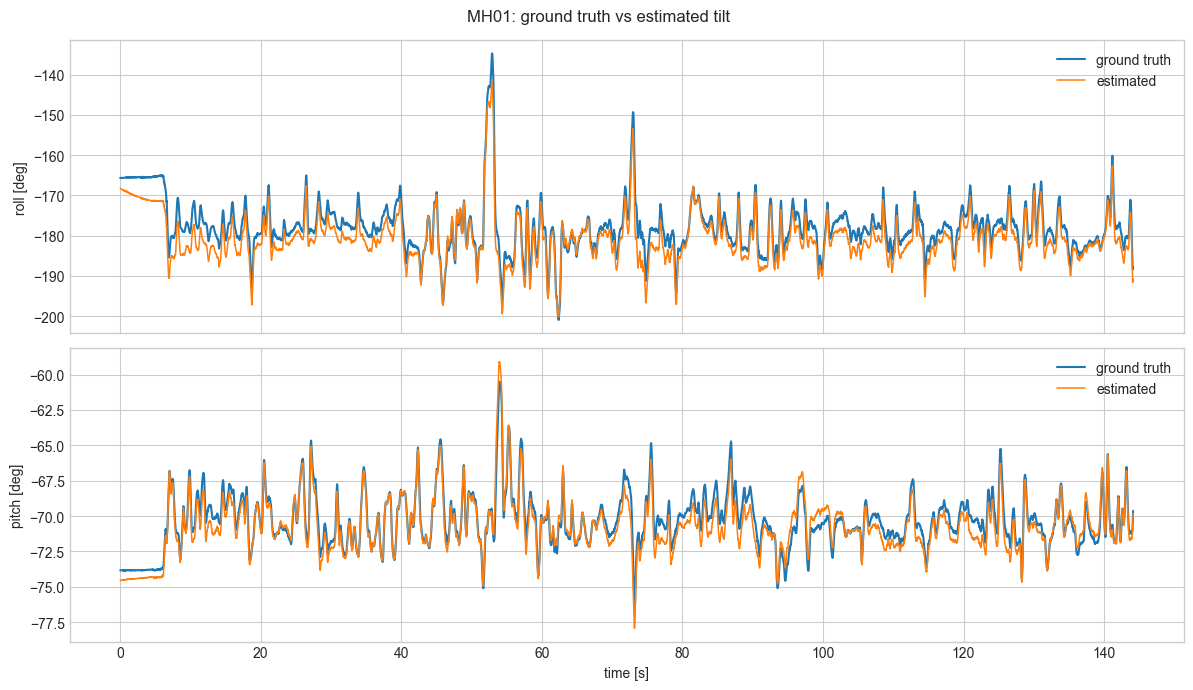

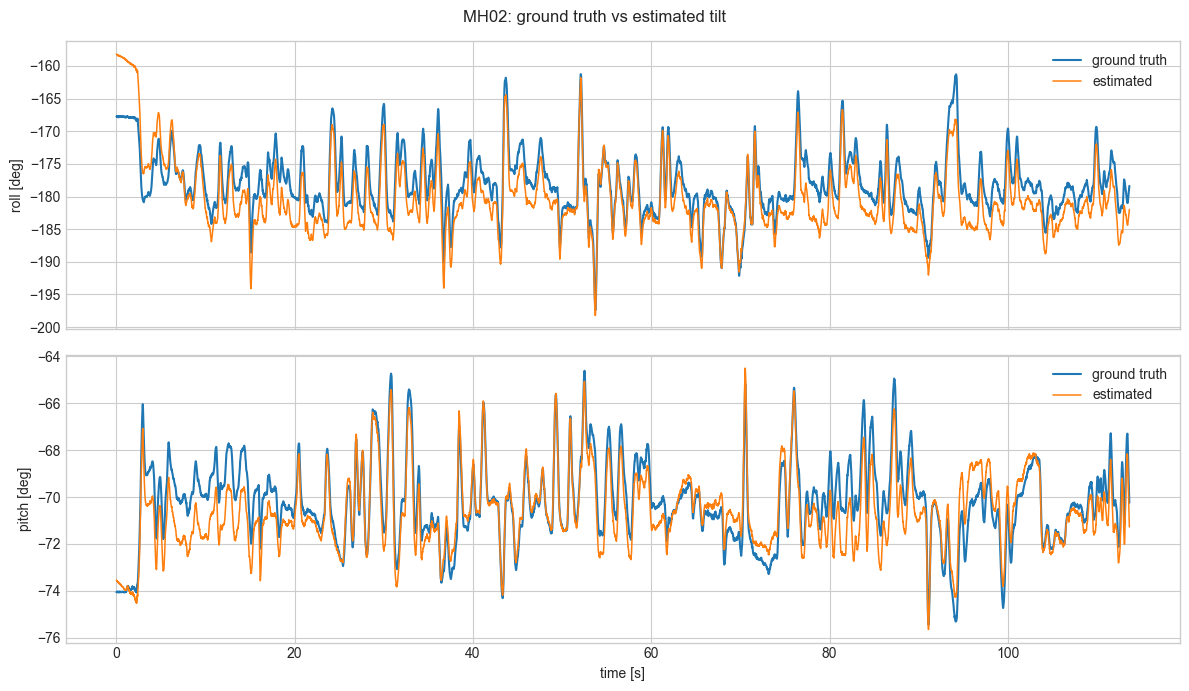

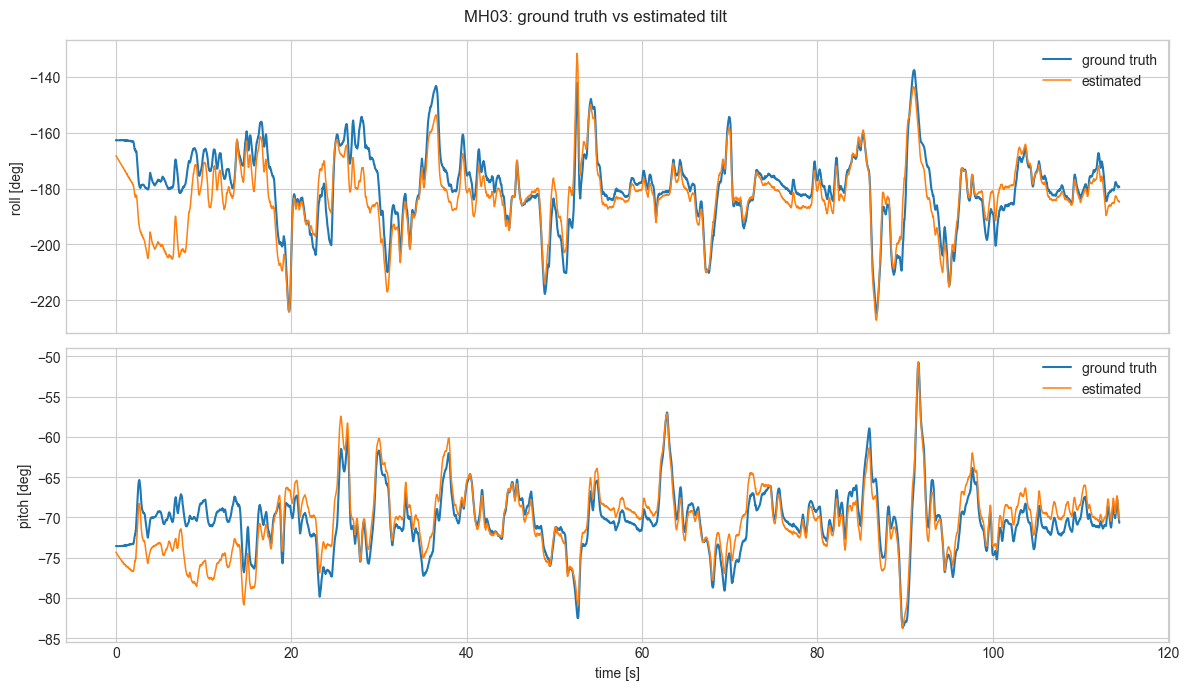

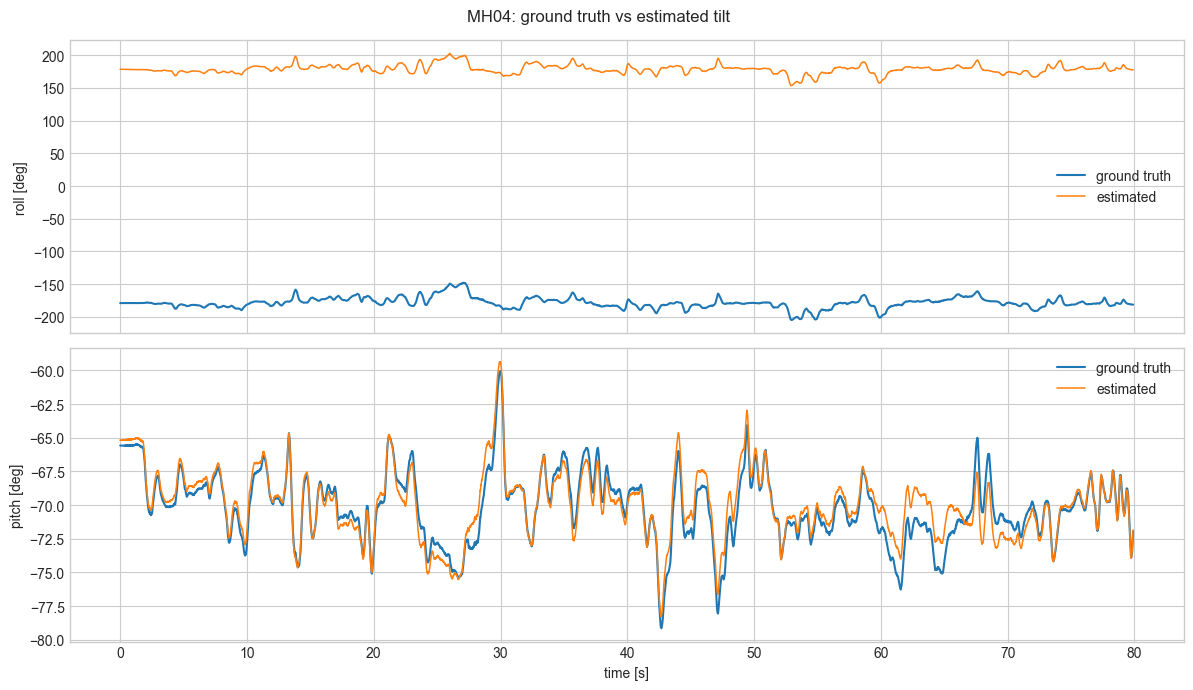

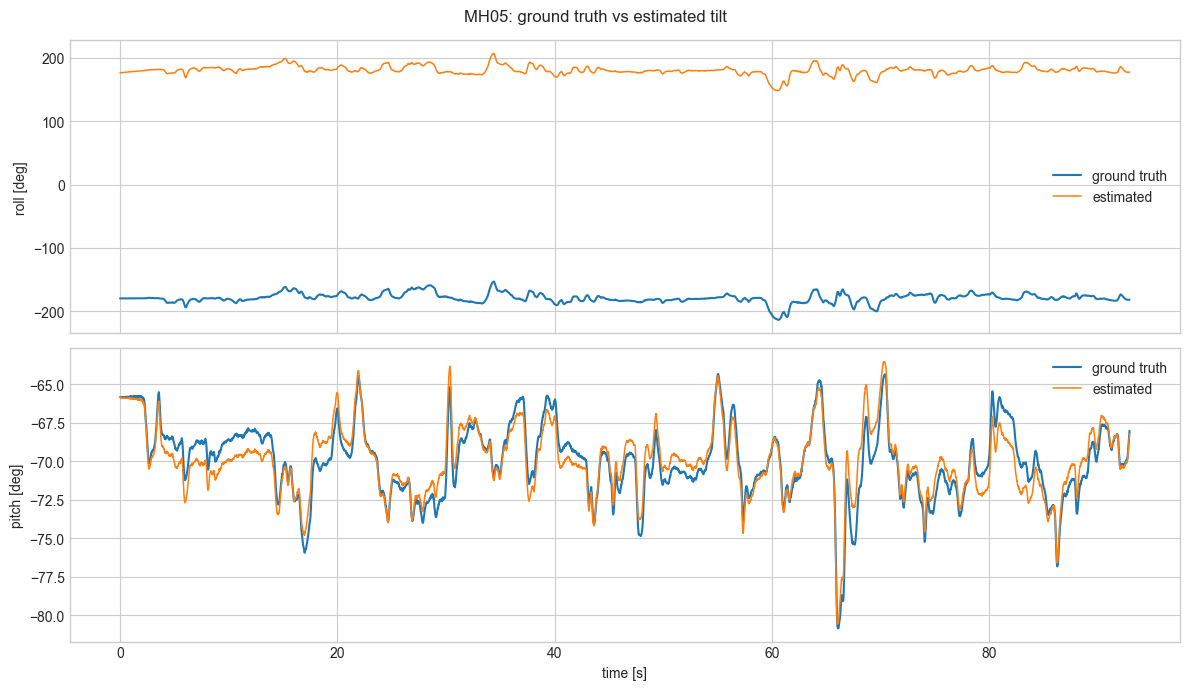

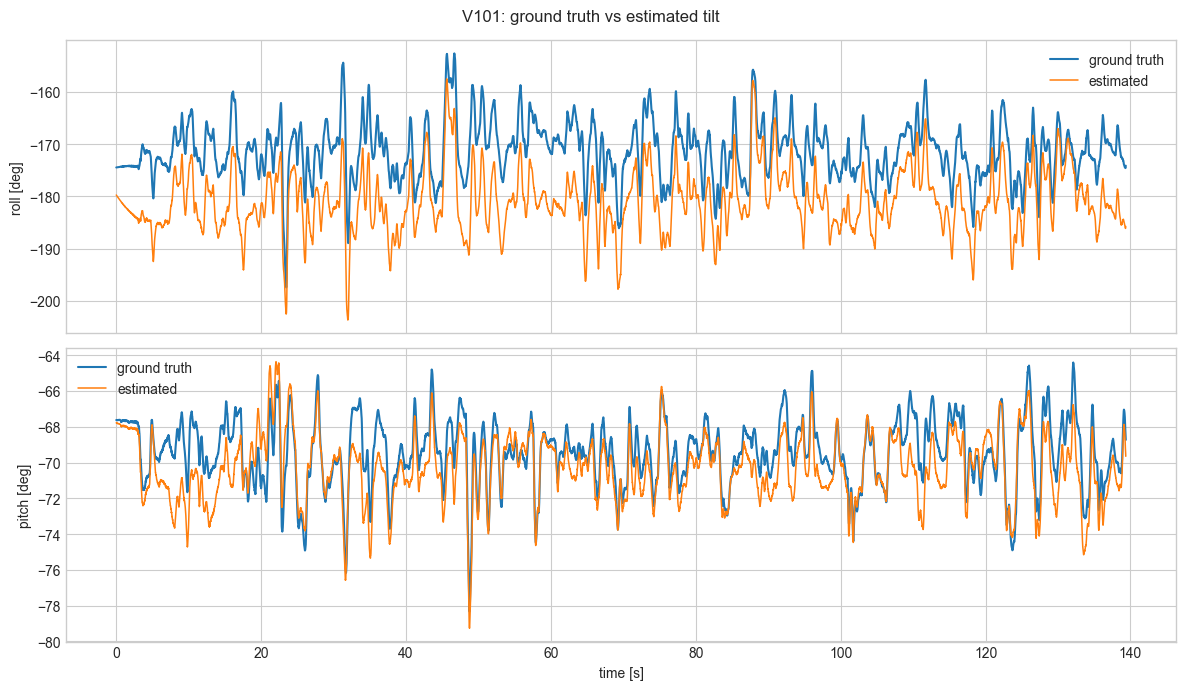

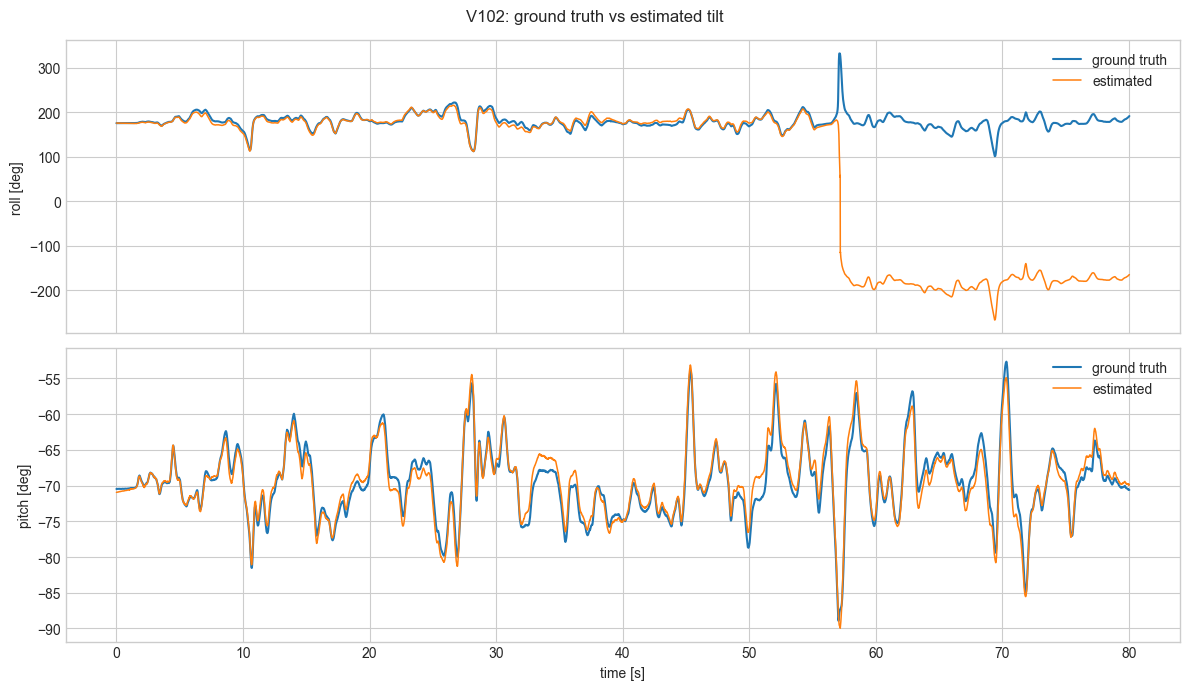

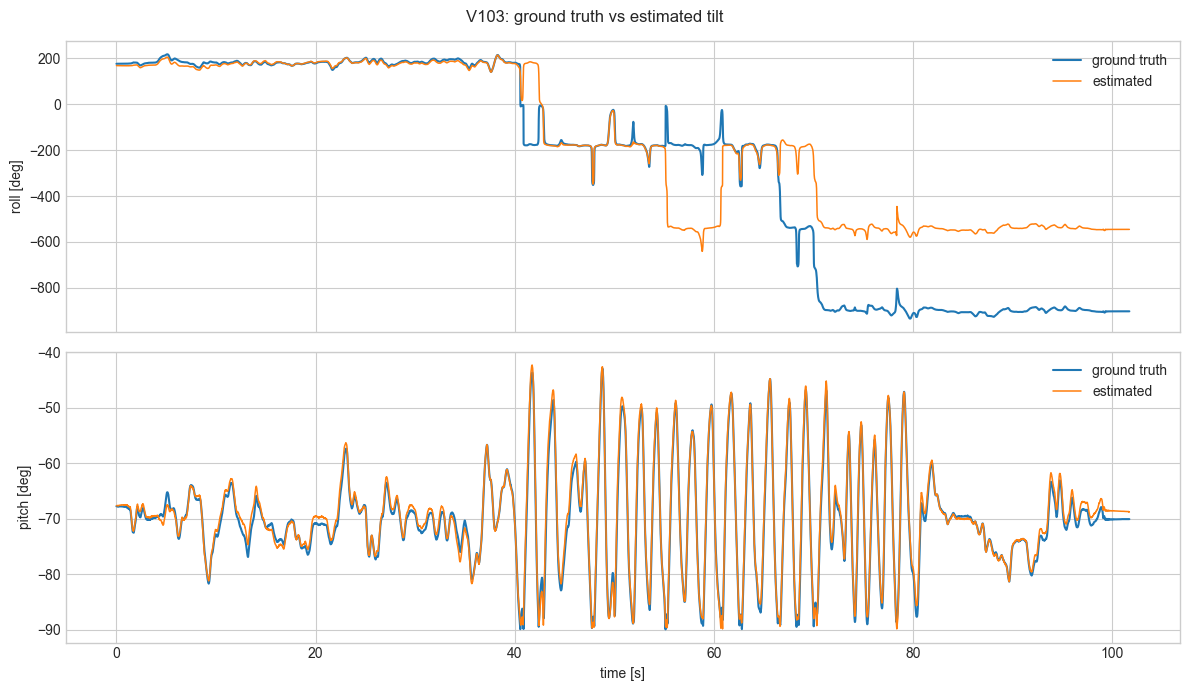

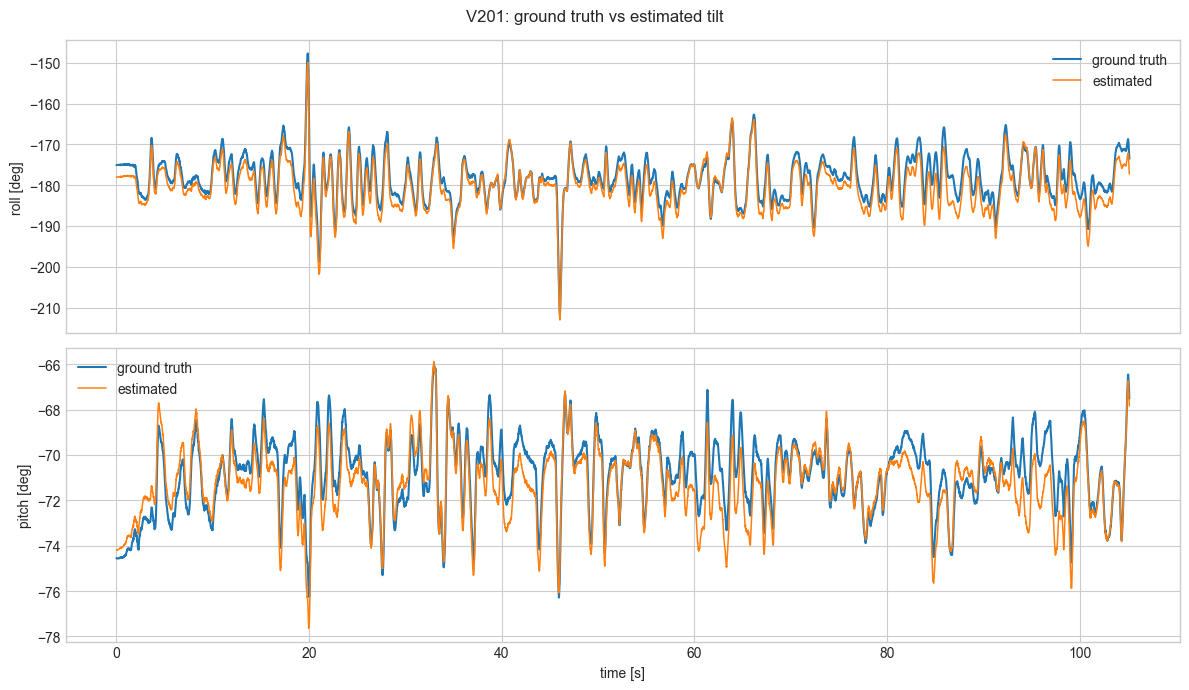

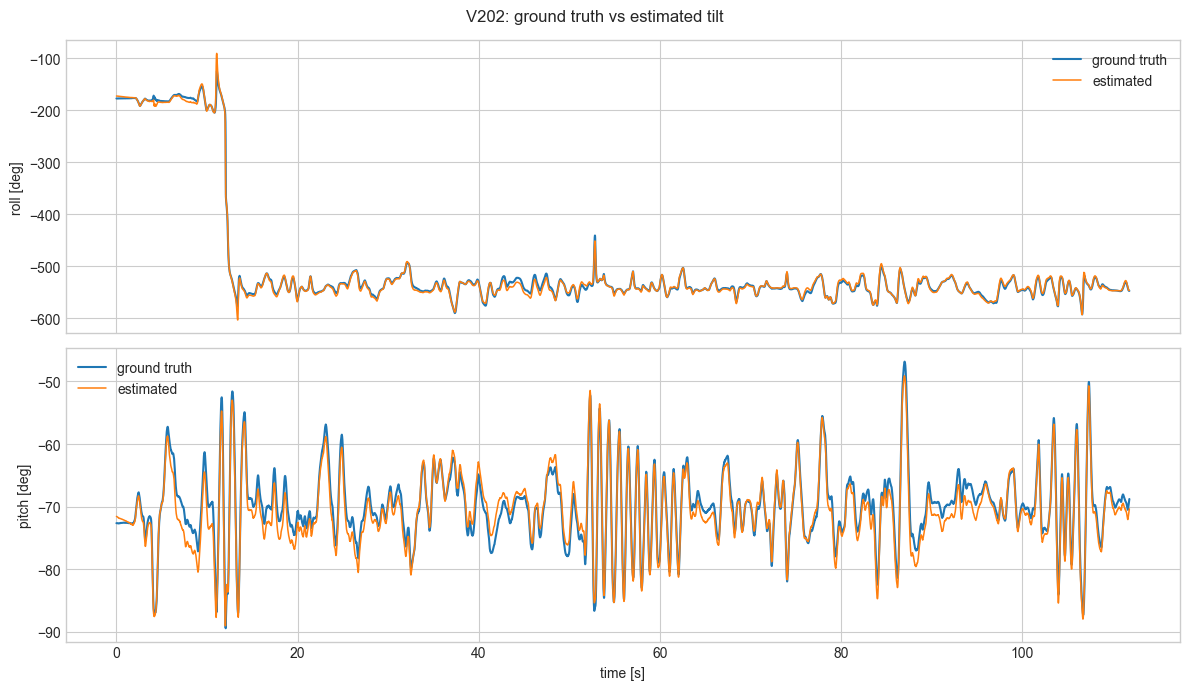

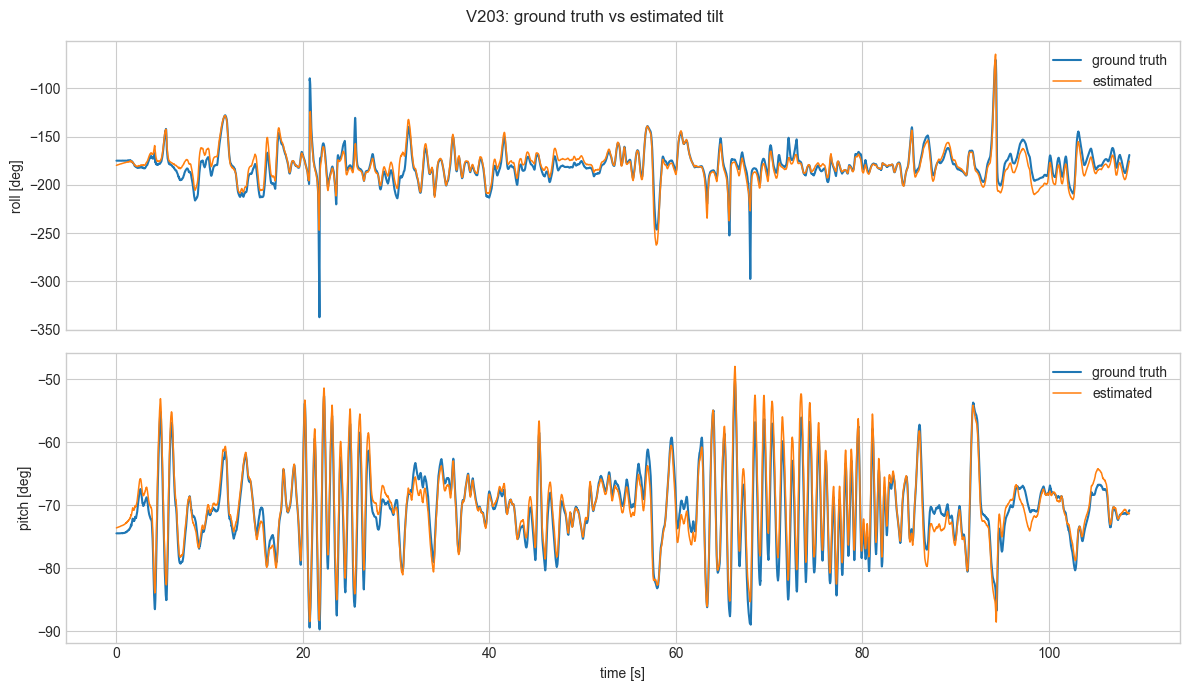

In [39]:
for dataset, df in data.groupby("dataset", sort=True):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"{dataset}: ground truth vs estimated tilt")

    axes[0].plot(df["timestamp"], df["gt_roll_deg"], label="ground truth")
    axes[0].plot(df["timestamp"], df["est_roll_deg"], label="estimated", linewidth=1.1)
    axes[0].set_ylabel("roll [deg]")
    axes[0].legend(loc="best")

    axes[1].plot(df["timestamp"], df["gt_pitch_deg"], label="ground truth")
    axes[1].plot(df["timestamp"], df["est_pitch_deg"], label="estimated", linewidth=1.1)
    axes[1].set_ylabel("pitch [deg]")
    axes[1].set_xlabel("time [s]")
    axes[1].legend(loc="best")

    fig.tight_layout()
    plt.show()

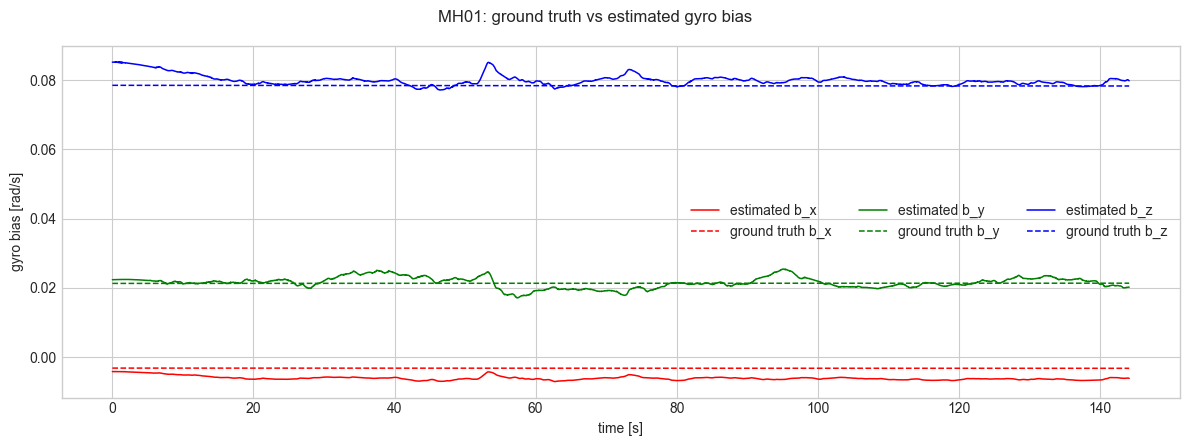

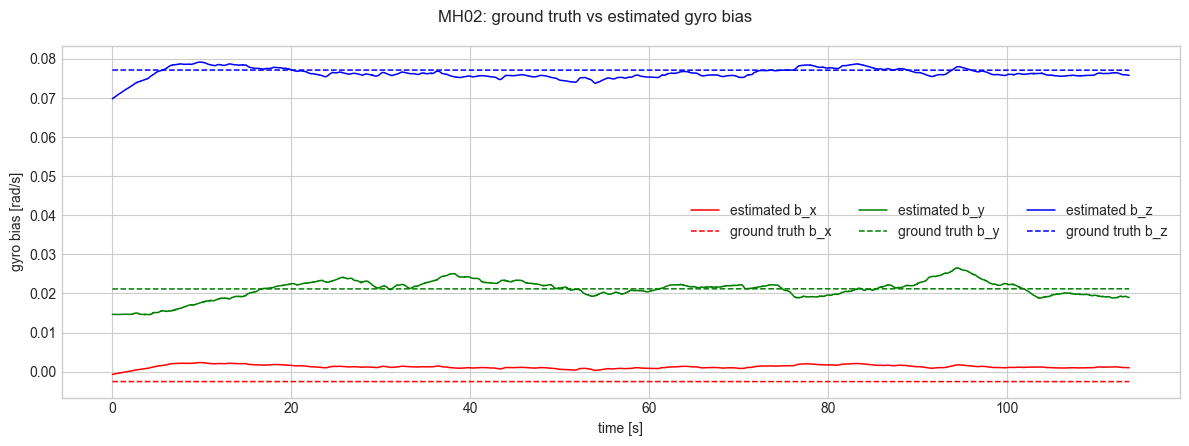

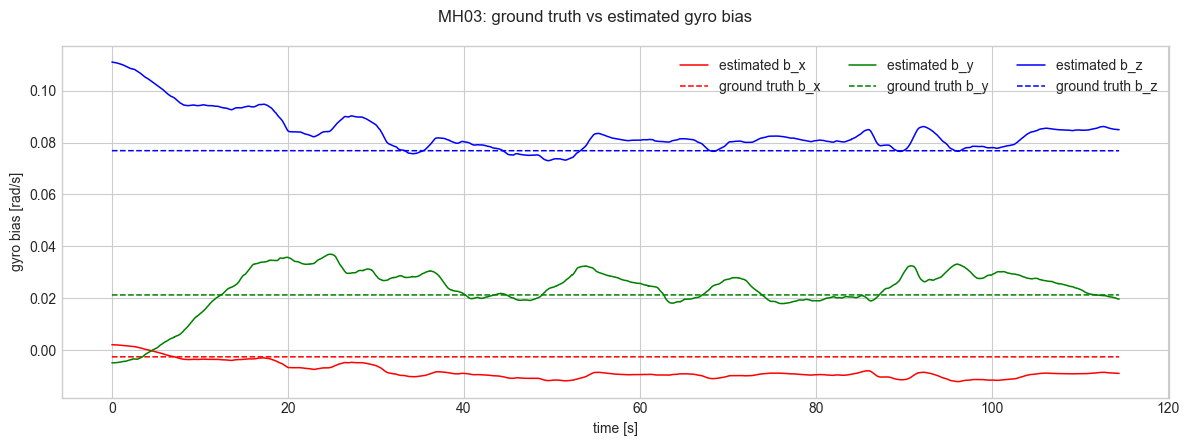

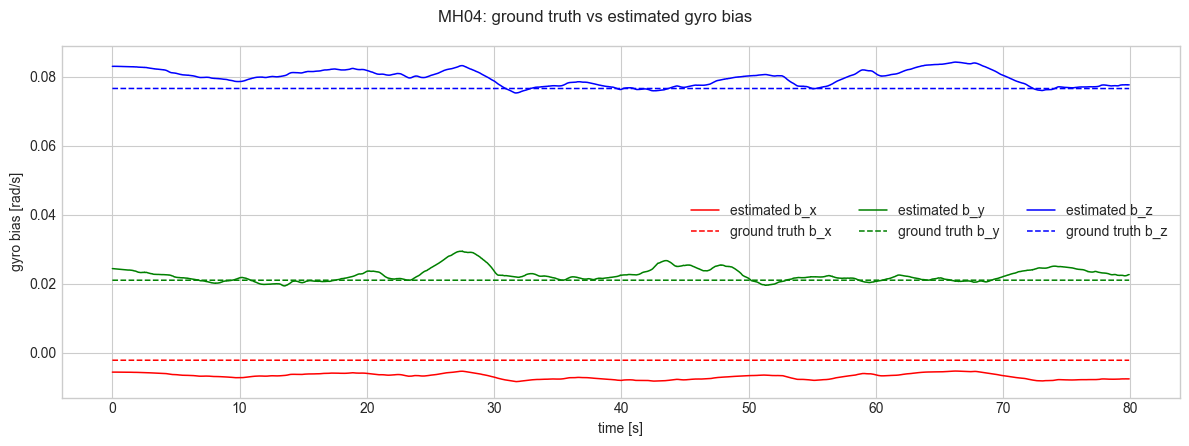

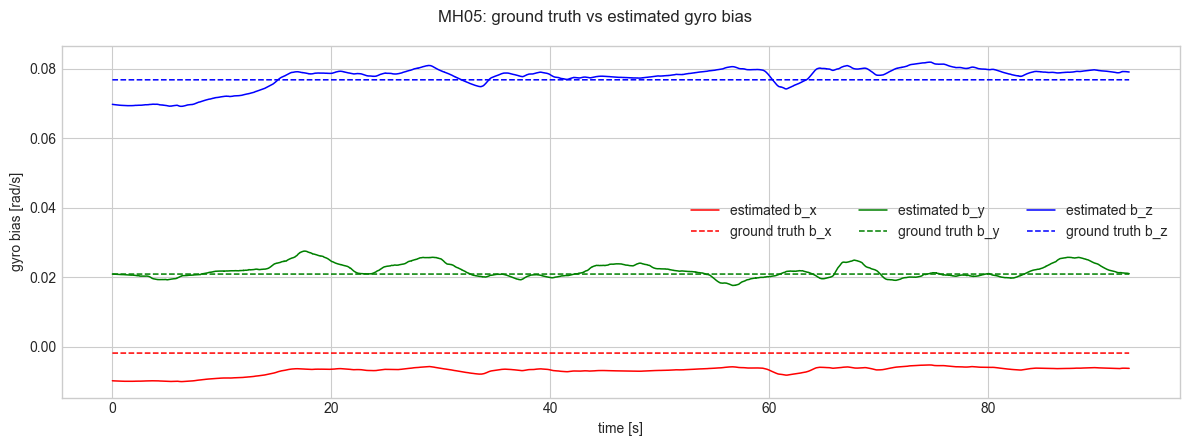

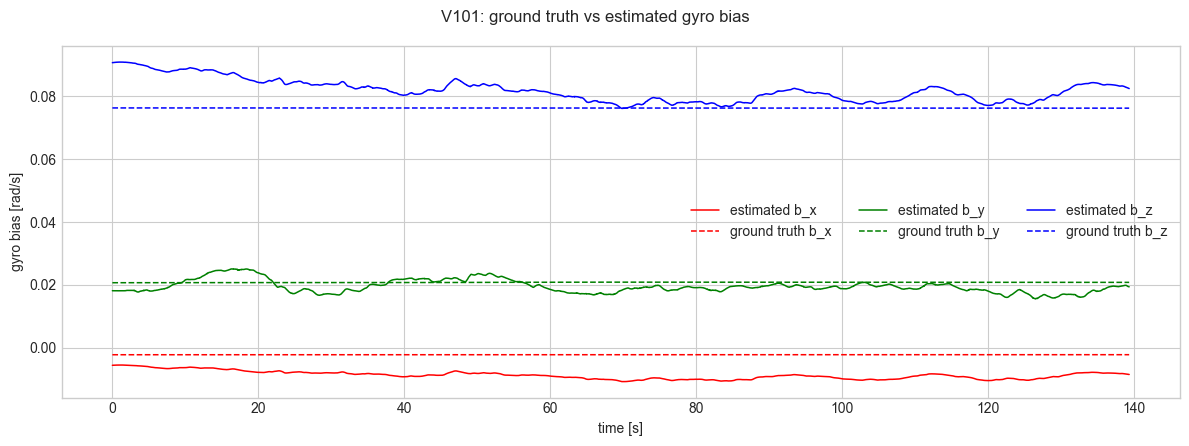

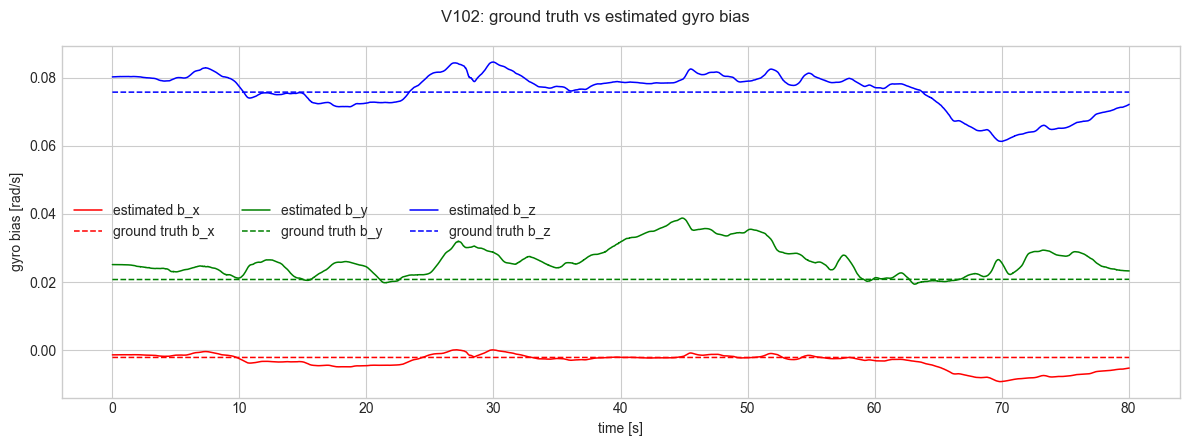

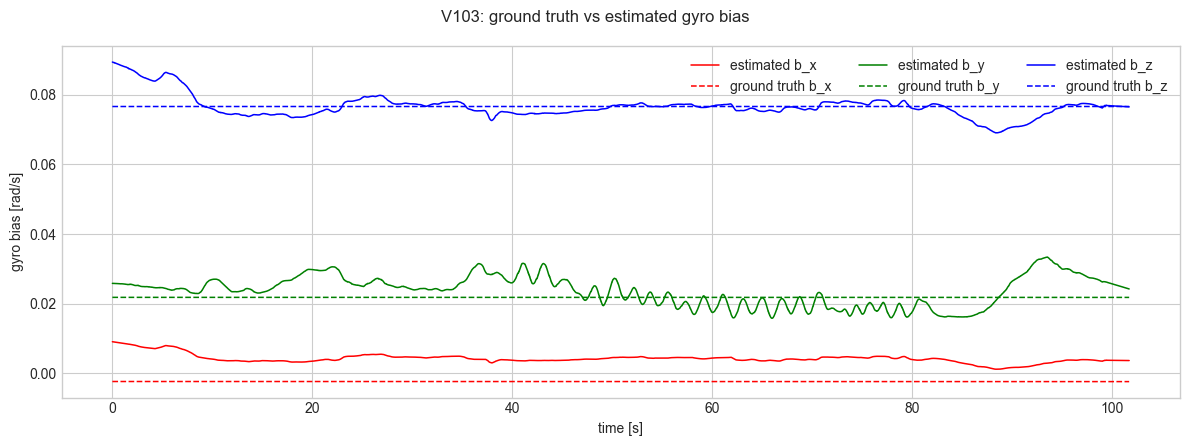

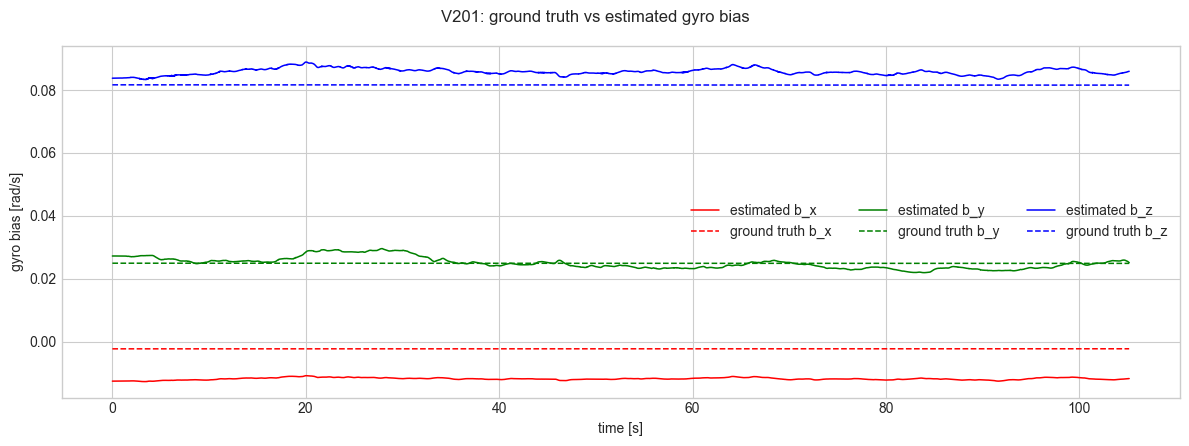

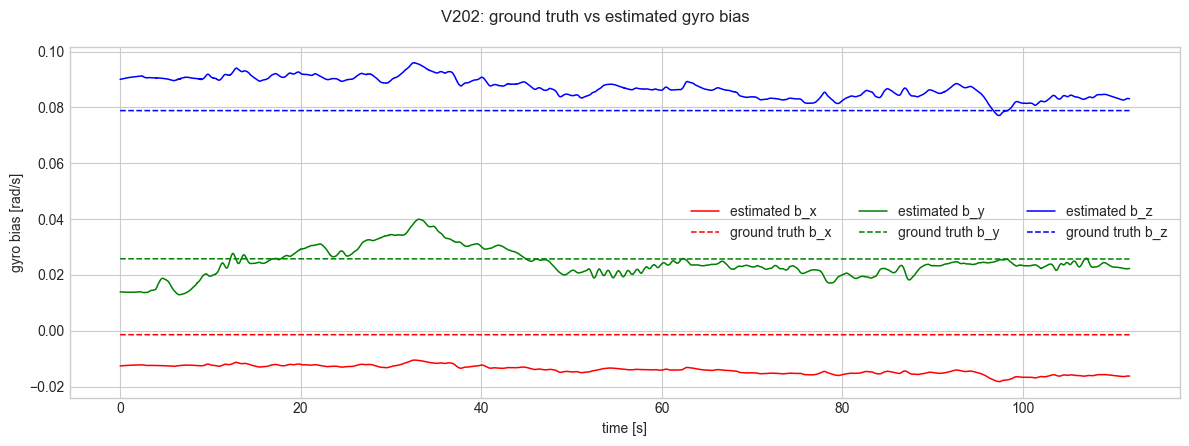

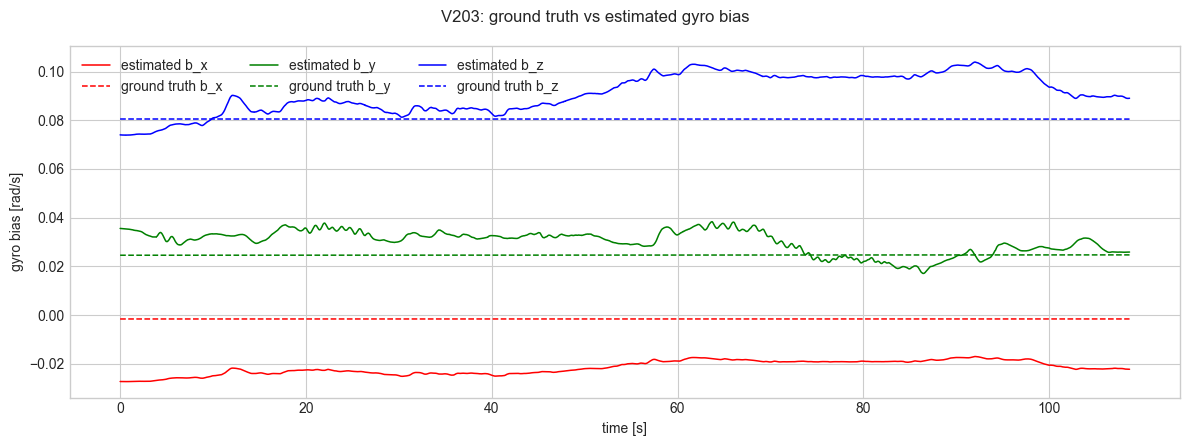

In [40]:
bias_axes = [
    ("x", "red"),
    ("y", "green"),
    ("z", "blue"),
]
for dataset, df in data.groupby("dataset", sort=True):
    fig, axis = plt.subplots(1, 1, figsize=(12, 4.5), sharex=True)
    fig.suptitle(f"{dataset}: ground truth vs estimated gyro bias")

    for component, color in bias_axes:
        axis.plot(
            df["timestamp"],
            df[f"est_gyro_bias_{component}"],
            color=color,
            linewidth=1.1,
            label=f"estimated b_{component}",
        )
        axis.plot(
            df["timestamp"],
            df[f"gt_gyro_bias_{component}"],
            color=color,
            linestyle="--",
            linewidth=1.1,
            label=f"ground truth b_{component}",
        )

    axis.set_ylabel("gyro bias [rad/s]")
    axis.set_xlabel("time [s]")
    axis.legend(loc="best", ncol=3)
    fig.tight_layout()
    plt.show()


## PIM Window-Rate Observer Results

This section discovers CSV files written by `evalPimTiltObserver`. By default it loads the latest run, which is useful for comparing the regular IMU-rate observer sampled at PIM endpoints against the observer updated once per PIM window from a PIM delta rotation and averaged specific force.


In [41]:
# Set PIM_RUN_DIR to a specific evalPimTiltObserver run directory to pin a run.
# For example:
# PIM_RUN_DIR = Path("../build/results/evalPimTiltObserver/20260505T015731077Z")
PIM_RUN_DIR = None

pim_candidate_roots = [
    notebook_dir / "../build/results/evalPimTiltObserver",
    notebook_dir / "../results/evalPimTiltObserver",
    notebook_dir / "build/results/evalPimTiltObserver",
    notebook_dir / "results/evalPimTiltObserver",
]

if PIM_RUN_DIR is None:
    pim_run_dirs = sorted({
        path.parent
        for root in pim_candidate_roots
        for path in root.glob("*/tilt_observer_pim_*.csv")
        if path.name != "tilt_observer_pim_summaries.csv"
    })
    if not pim_run_dirs:
        raise FileNotFoundError("No PIM tilt observer CSV files found. Run ./evalPimTiltObserver from the build directory first.")
    pim_run_dir = pim_run_dirs[-1]
else:
    pim_run_dir = Path(PIM_RUN_DIR).expanduser().resolve()

pim_csv_files = sorted(
    path for path in pim_run_dir.glob("tilt_observer_pim_*.csv")
    if path.name != "tilt_observer_pim_summaries.csv"
)
if not pim_csv_files:
    raise FileNotFoundError(f"No PIM tilt observer CSV files found in {pim_run_dir}")

pim_frames = [pd.read_csv(path) for path in pim_csv_files]
pim_data = pd.concat(pim_frames, ignore_index=True)
pim_data = pim_data.sort_values(["dataset", "method", "window_index"]).reset_index(drop=True)

pim_angle_columns = ["gt_roll_rad", "gt_pitch_rad", "est_roll_rad", "est_pitch_rad"]
for column in pim_angle_columns:
    unwrapped = pim_data.groupby(["dataset", "method"])[column].transform(lambda values: np.unwrap(values.to_numpy()))
    pim_data[column.replace("_rad", "_unwrapped_rad")] = unwrapped
    pim_data[column.replace("_rad", "_deg")] = np.degrees(unwrapped)

pim_summary_path = pim_run_dir / "tilt_observer_pim_summaries.csv"
pim_summaries = pd.read_csv(pim_summary_path) if pim_summary_path.exists() else pd.DataFrame()
if not pim_summaries.empty:
    pim_summaries = pim_summaries.assign(
        roll_rmse_deg=np.degrees(pim_summaries["roll_rmse_rad"]),
        pitch_rmse_deg=np.degrees(pim_summaries["pitch_rmse_rad"]),
    )

print(f"Loaded {len(pim_csv_files)} PIM tilt observer CSV files from {pim_run_dir}")
if not pim_summaries.empty:
    display(
        pim_summaries[[
            "dataset",
            "method",
            "interval_seconds",
            "samples_per_window",
            "num_windows",
            "roll_rmse_deg",
            "pitch_rmse_deg",
            "bias_vector_rmse",
        ]]
    )
else:
    display(pim_data.groupby(["dataset", "method"]).agg(windows=("window_index", "count"), duration_s=("timestamp", "max")))


Loaded 11 PIM tilt observer CSV files from /Users/dellaert/git/imuFactors/notebooks/../build/results/evalPimTiltObserver/20260505T024243068Z


,dataset,method,interval_seconds,samples_per_window,num_windows,roll_rmse_deg,pitch_rmse_deg,bias_vector_rmse
0,MH01,imu_rate,1,200,144,2.774574,0.697021,0.002053
1,MH01,pim_window,1,200,144,3.159003,0.806320,0.002959
2,MH02,imu_rate,1,200,113,2.852104,0.768344,0.001916
3,MH02,pim_window,1,200,113,2.965113,0.985487,0.002429
4,MH03,imu_rate,1,200,114,4.918439,1.399482,0.006528
...,...,...,...,...,...,...,...,...
17,V201,pim_window,1,200,105,3.319707,0.909938,0.003404
18,V202,imu_rate,1,200,111,2.854069,1.212962,0.004923
19,V202,pim_window,1,200,111,7.085018,2.110185,0.009585
20,V203,imu_rate,1,200,108,8.380846,1.536085,0.009274


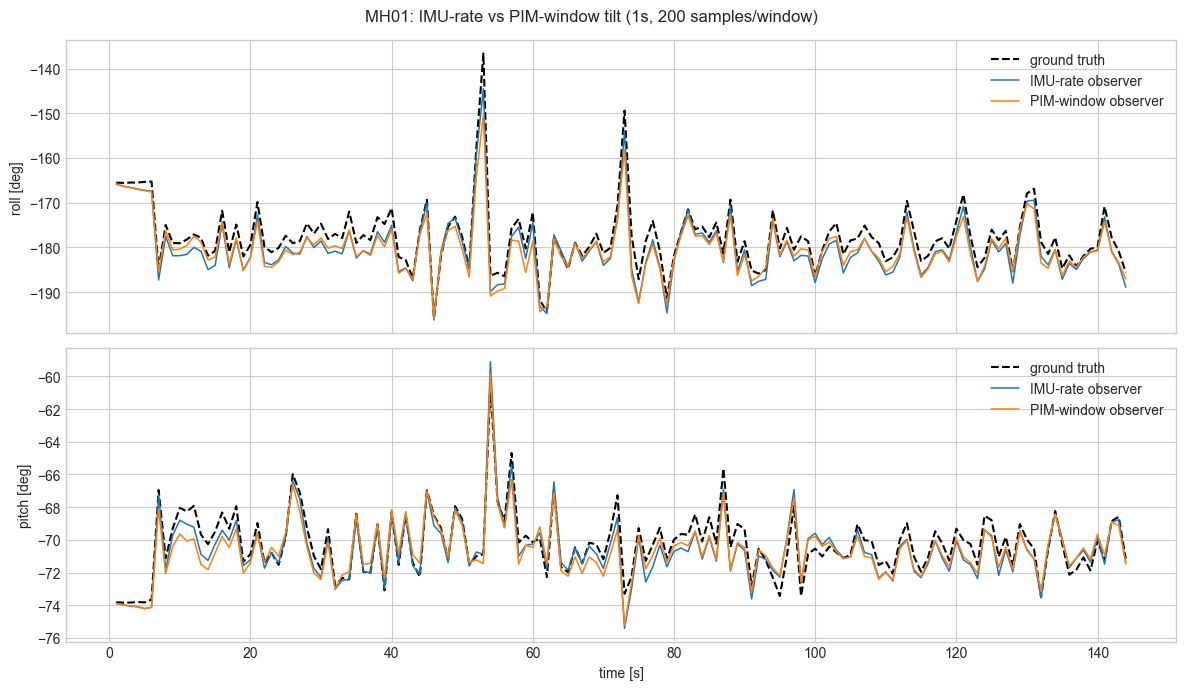

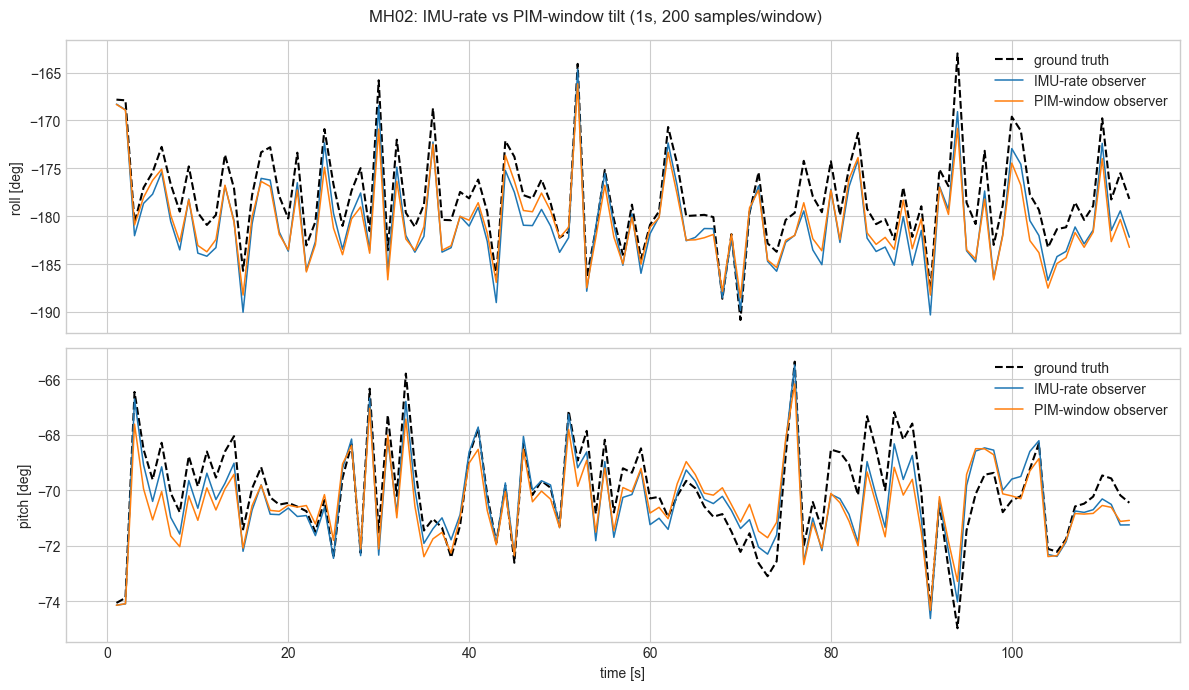

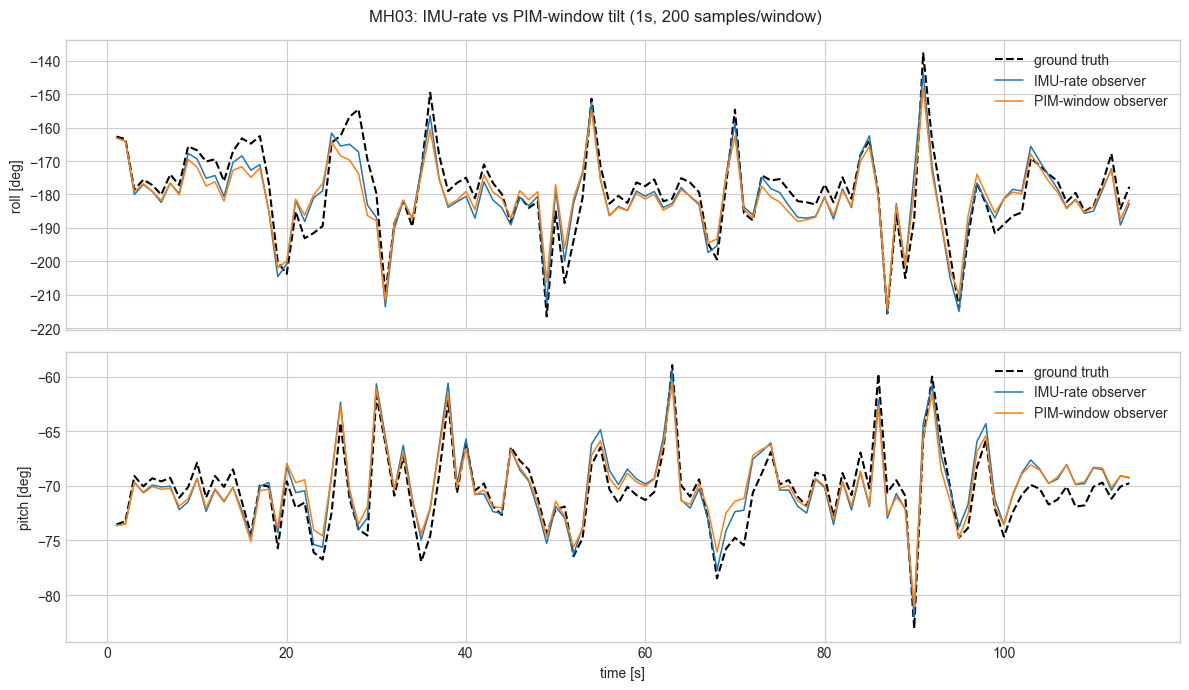

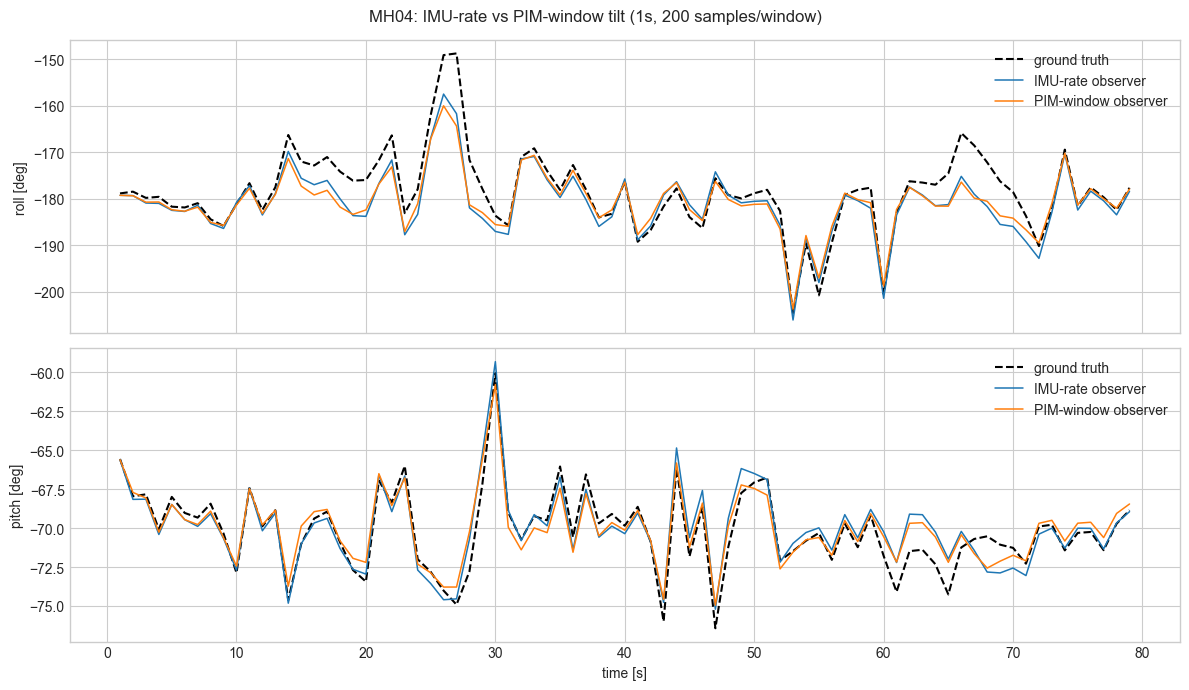

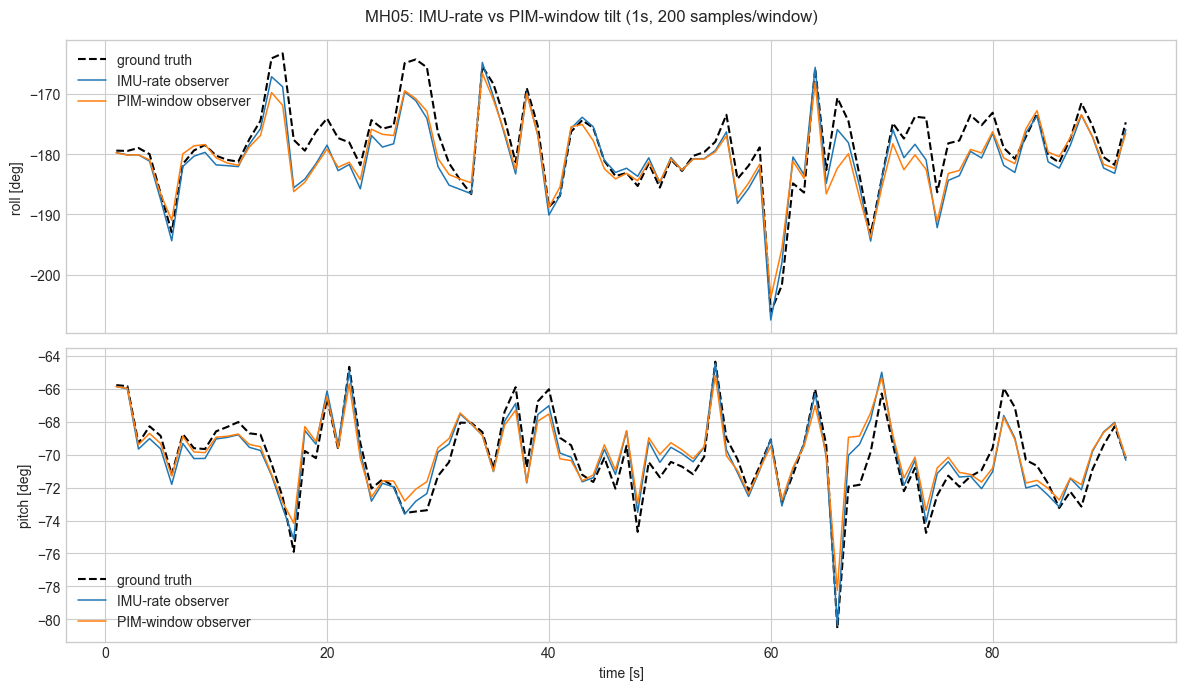

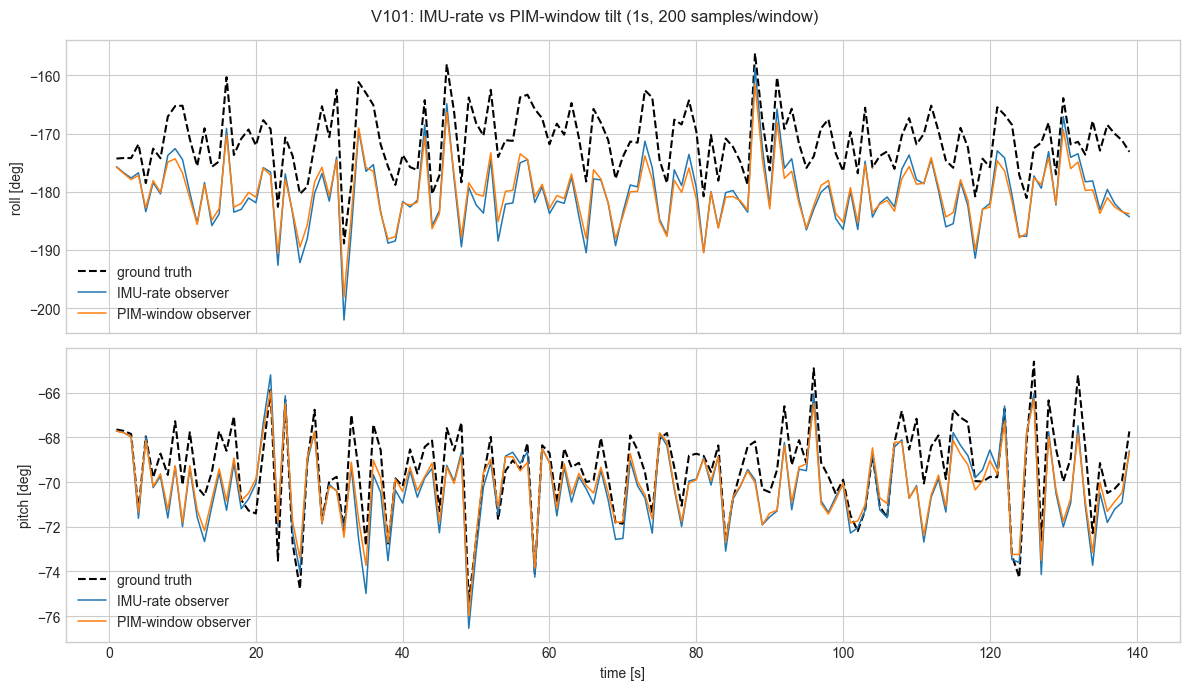

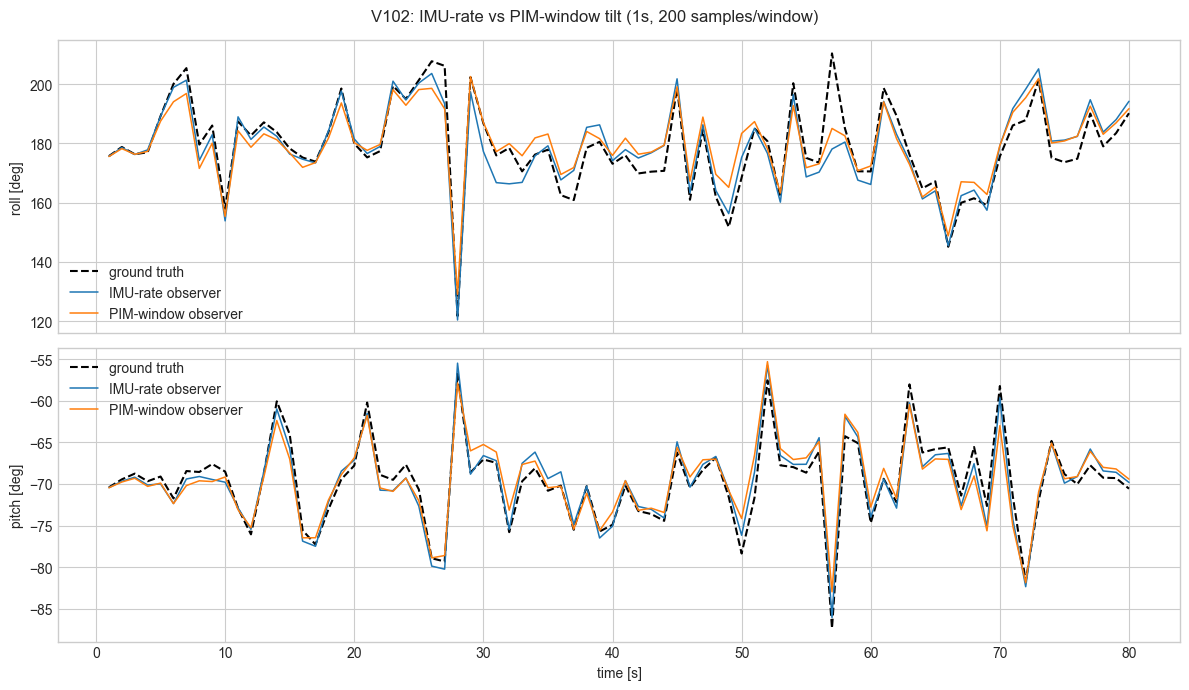

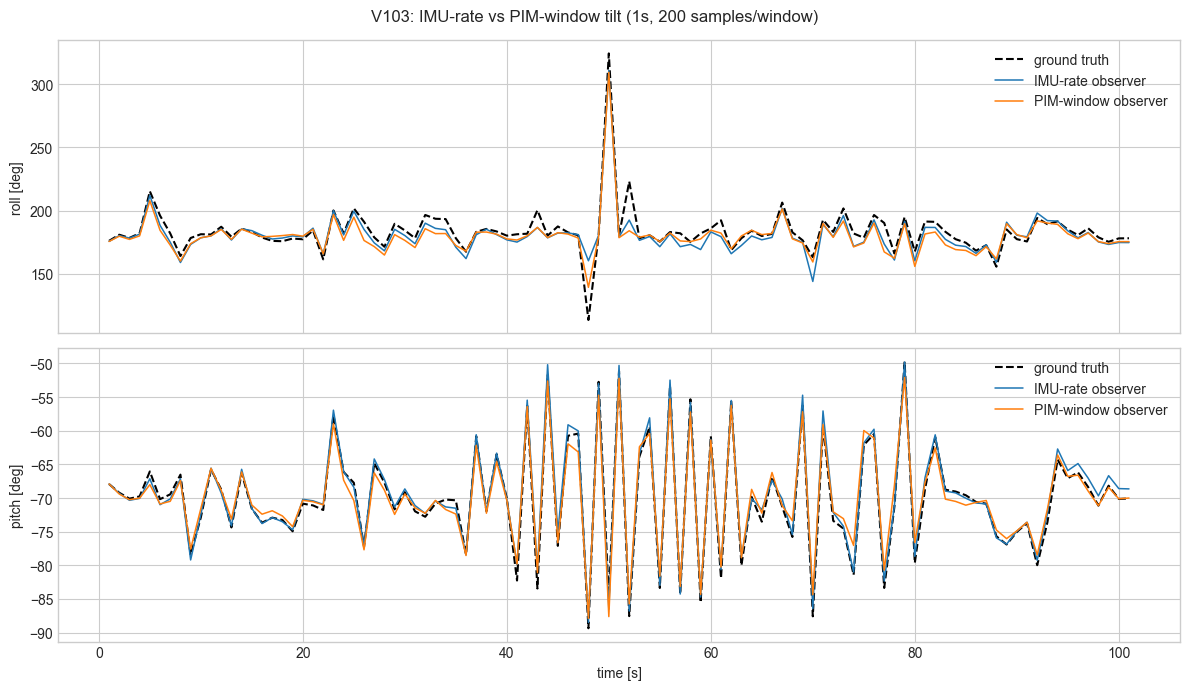

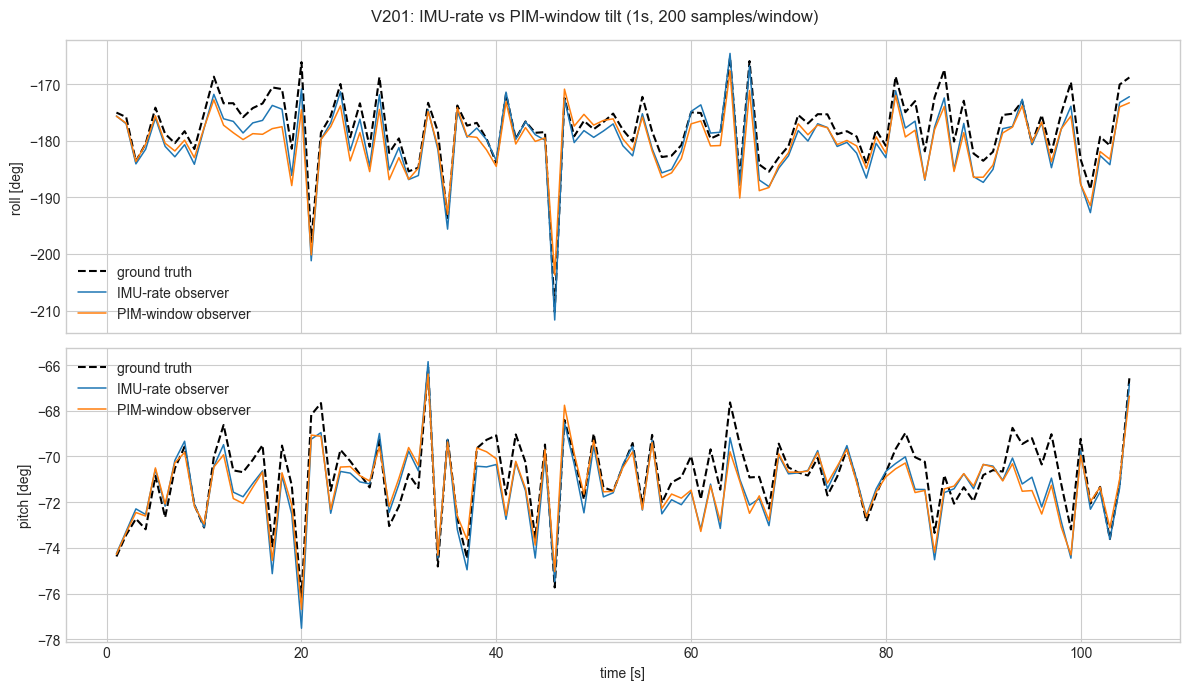

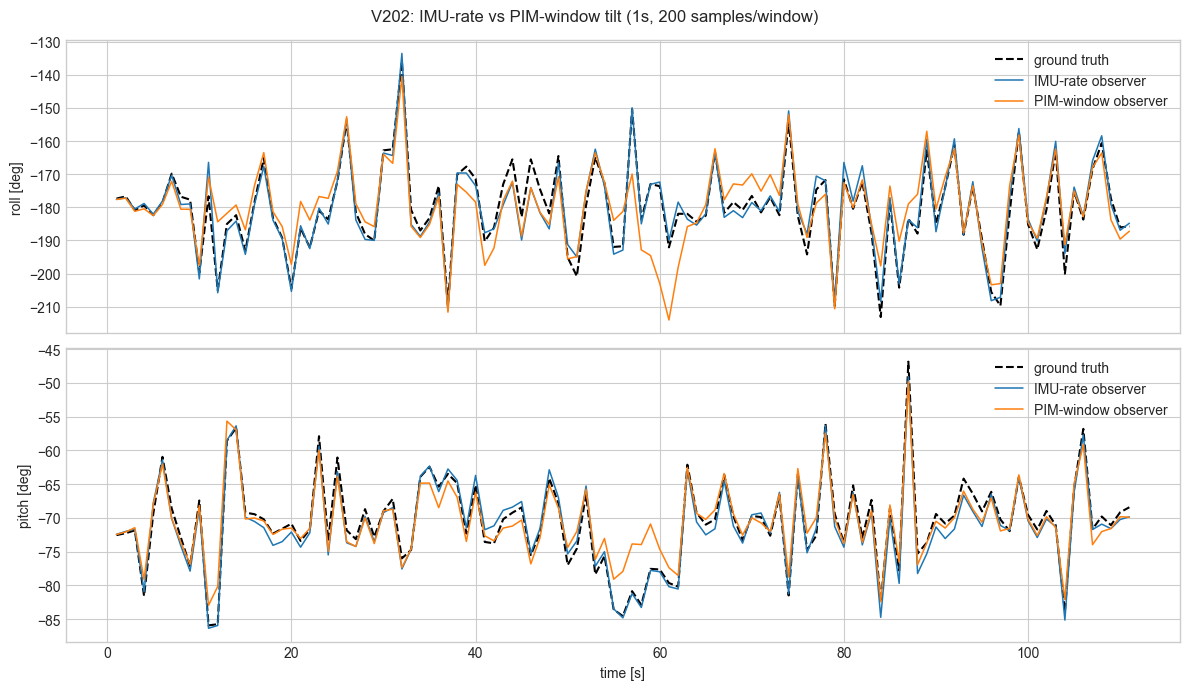

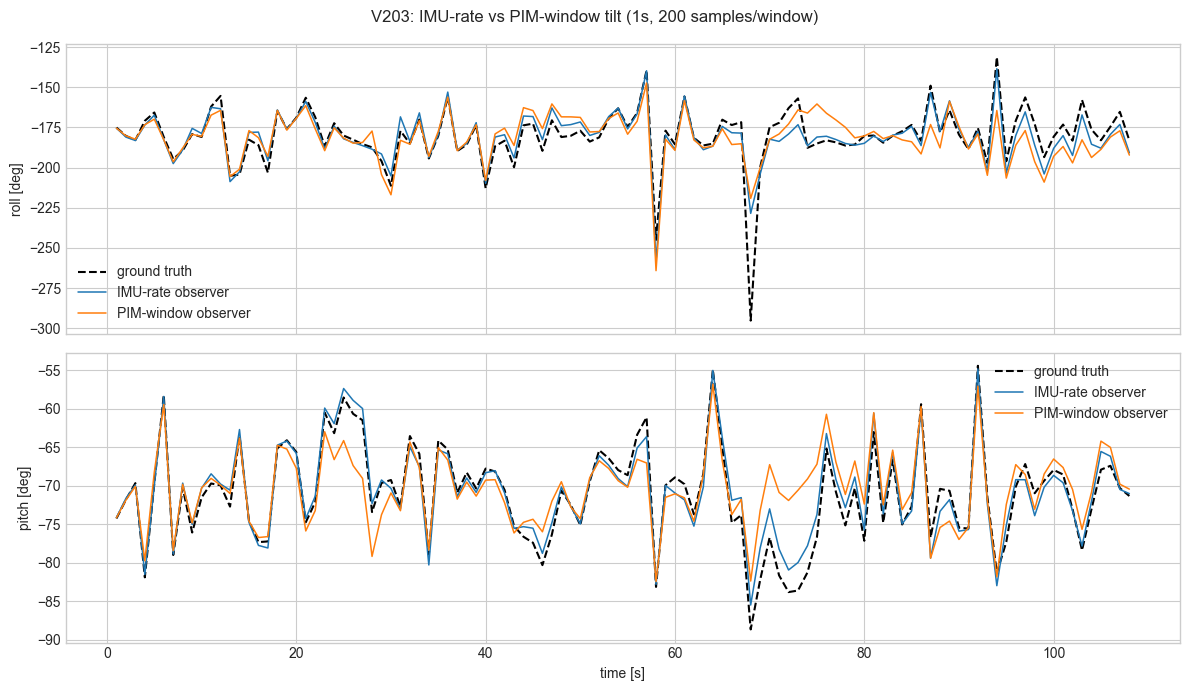

In [42]:
method_styles = {
    "imu_rate": {"color": "tab:blue", "label": "IMU-rate observer"},
    "pim_window": {"color": "tab:orange", "label": "PIM-window observer"},
}

for dataset, dataset_df in pim_data.groupby("dataset", sort=True):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    interval = dataset_df["interval_seconds"].iloc[0]
    samples = dataset_df["samples_per_window"].iloc[0]
    fig.suptitle(f"{dataset}: IMU-rate vs PIM-window tilt ({interval:g}s, {samples} samples/window)")

    reference = dataset_df[dataset_df["method"] == dataset_df["method"].iloc[0]]
    axes[0].plot(reference["timestamp"], reference["gt_roll_deg"], color="black", linestyle="--", label="ground truth")
    axes[1].plot(reference["timestamp"], reference["gt_pitch_deg"], color="black", linestyle="--", label="ground truth")

    for method, method_df in dataset_df.groupby("method", sort=True):
        style = method_styles.get(method, {"color": None, "label": method})
        axes[0].plot(method_df["timestamp"], method_df["est_roll_deg"], color=style["color"], linewidth=1.1, label=style["label"])
        axes[1].plot(method_df["timestamp"], method_df["est_pitch_deg"], color=style["color"], linewidth=1.1, label=style["label"])

    axes[0].set_ylabel("roll [deg]")
    axes[0].legend(loc="best")
    axes[1].set_ylabel("pitch [deg]")
    axes[1].set_xlabel("time [s]")
    axes[1].legend(loc="best")
    fig.tight_layout()
    plt.show()


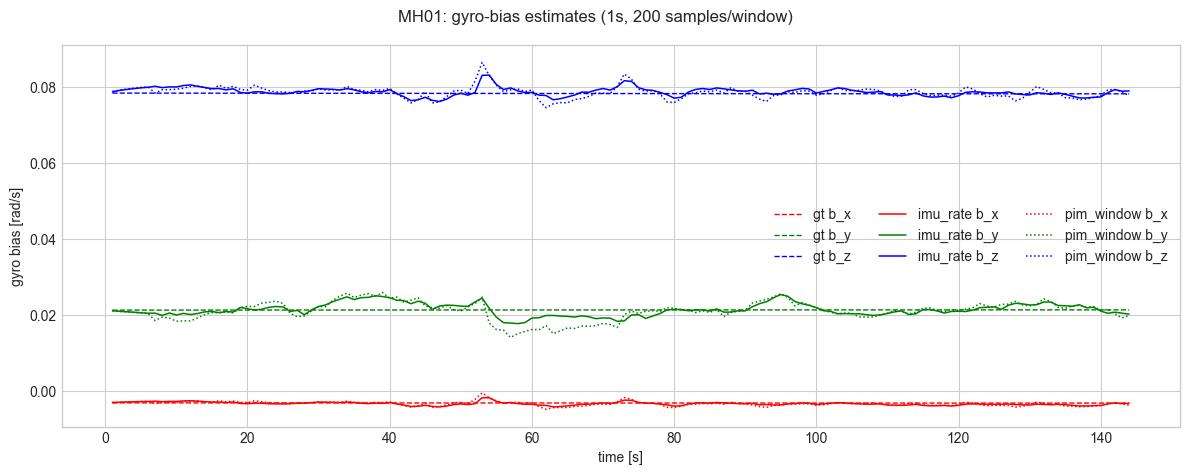

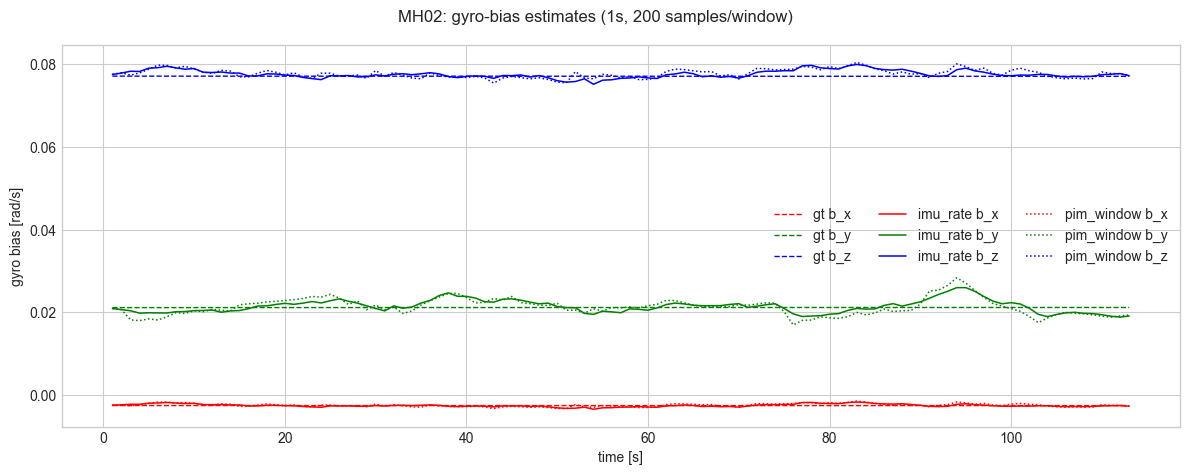

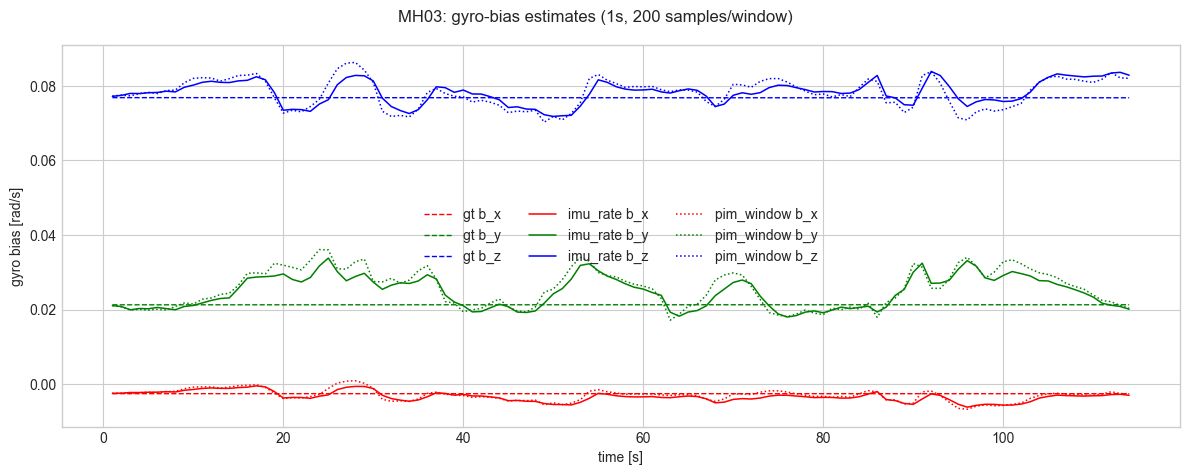

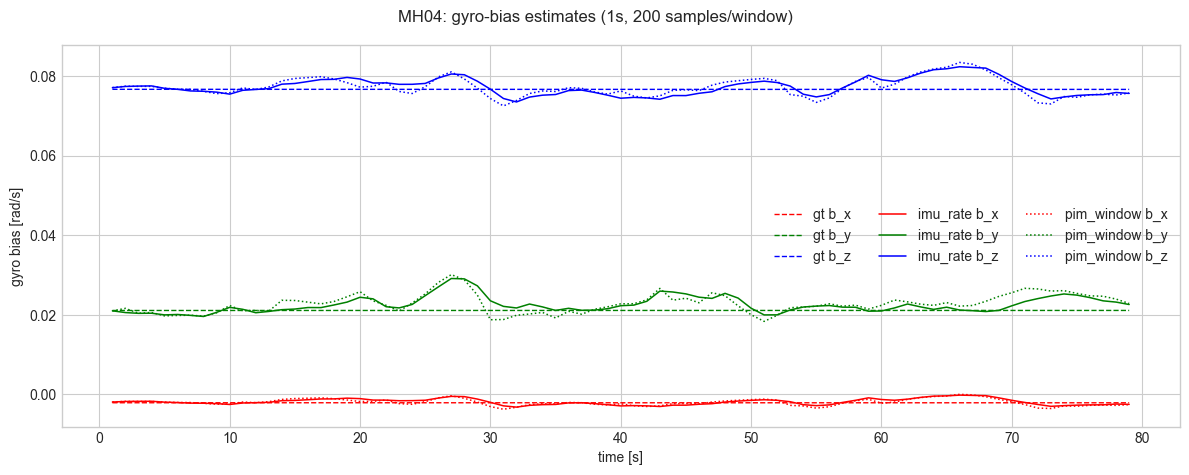

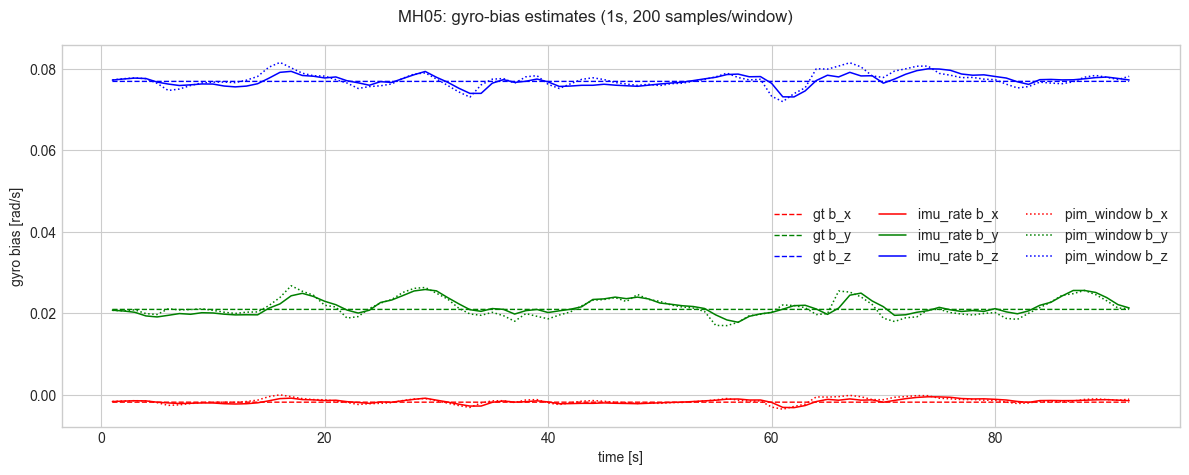

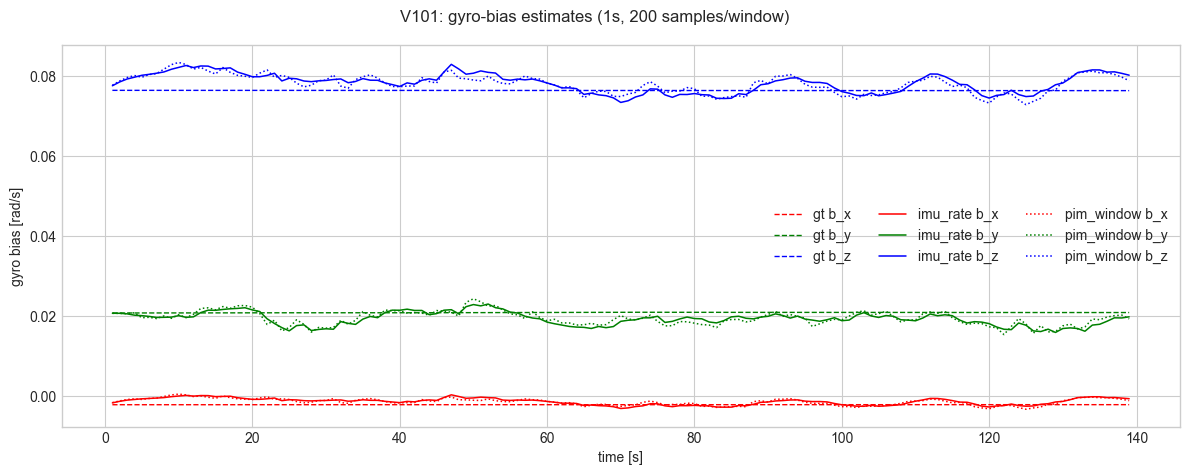

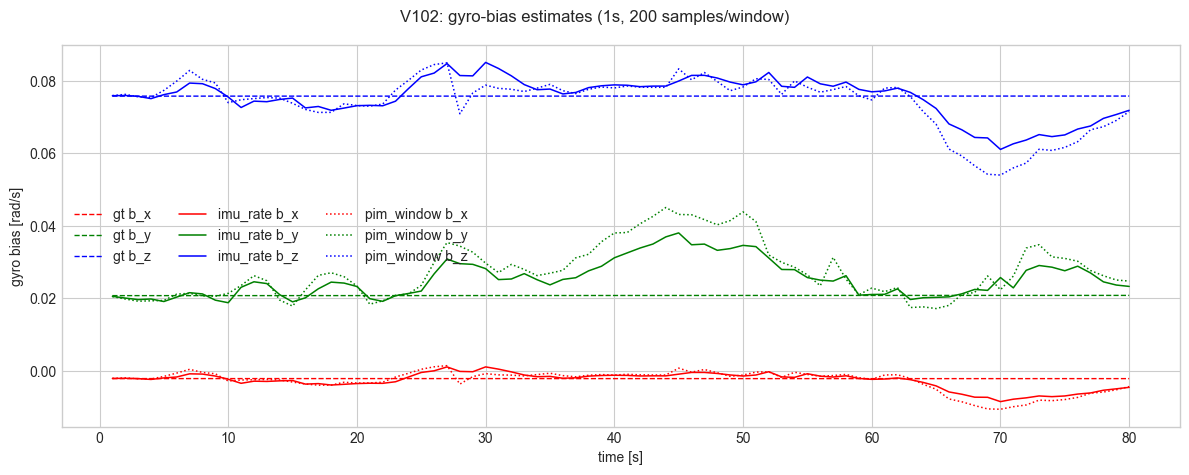

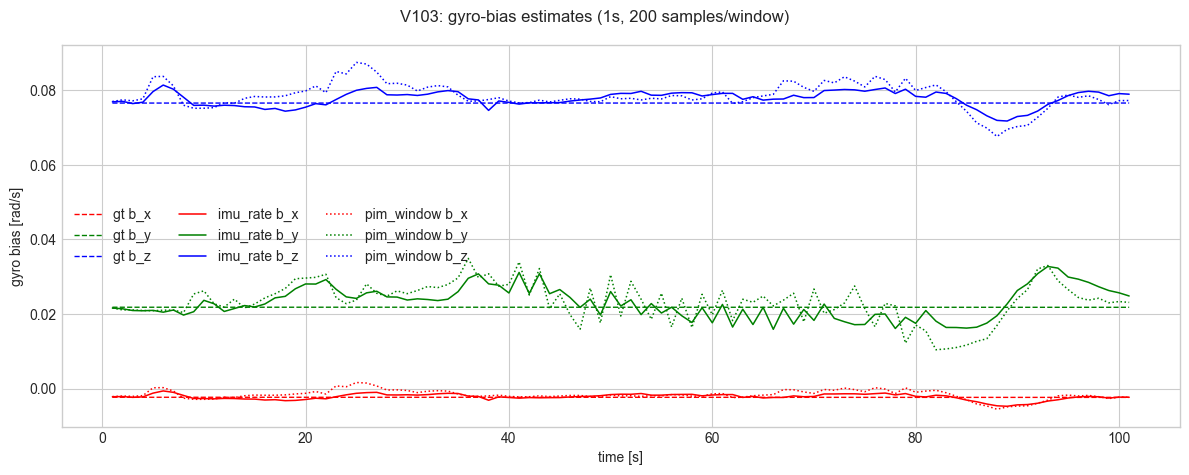

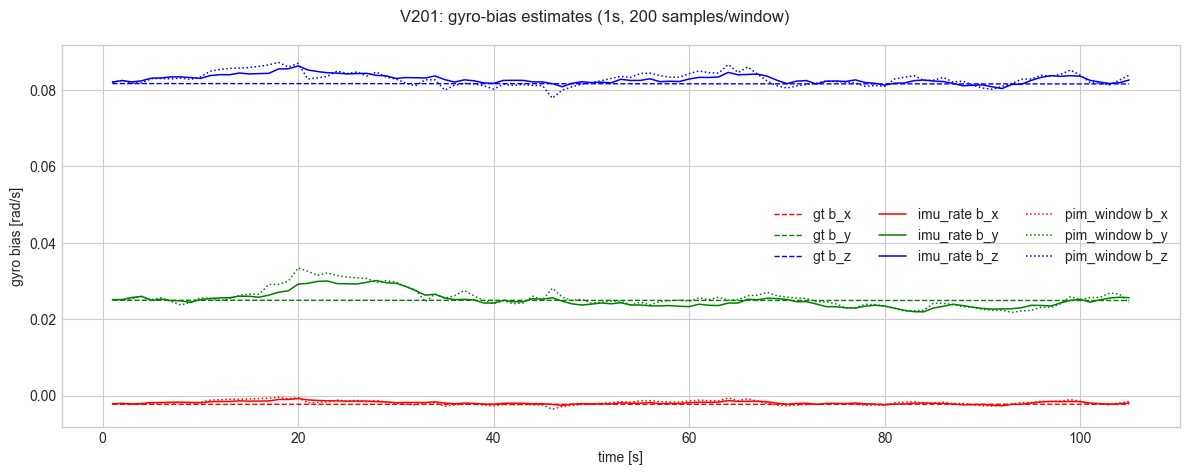

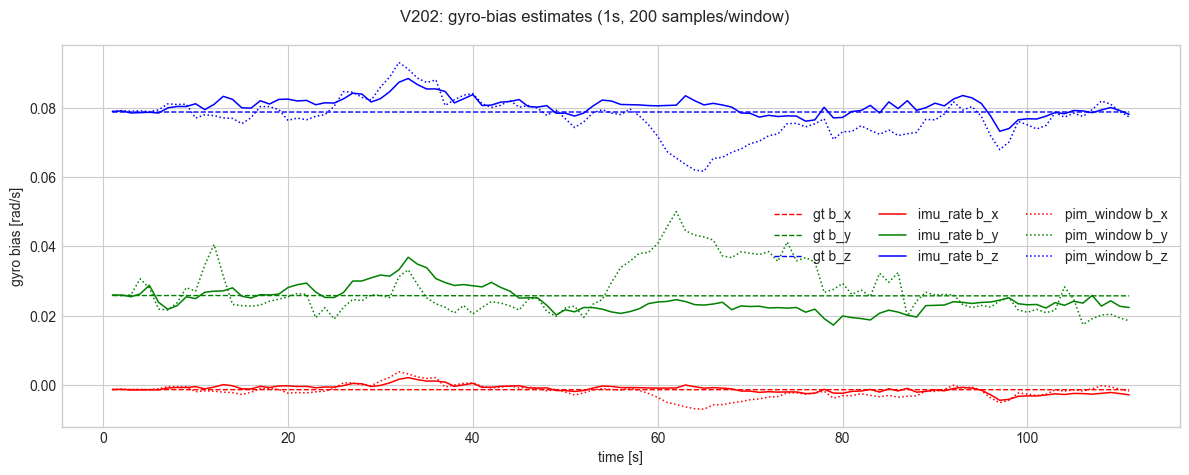

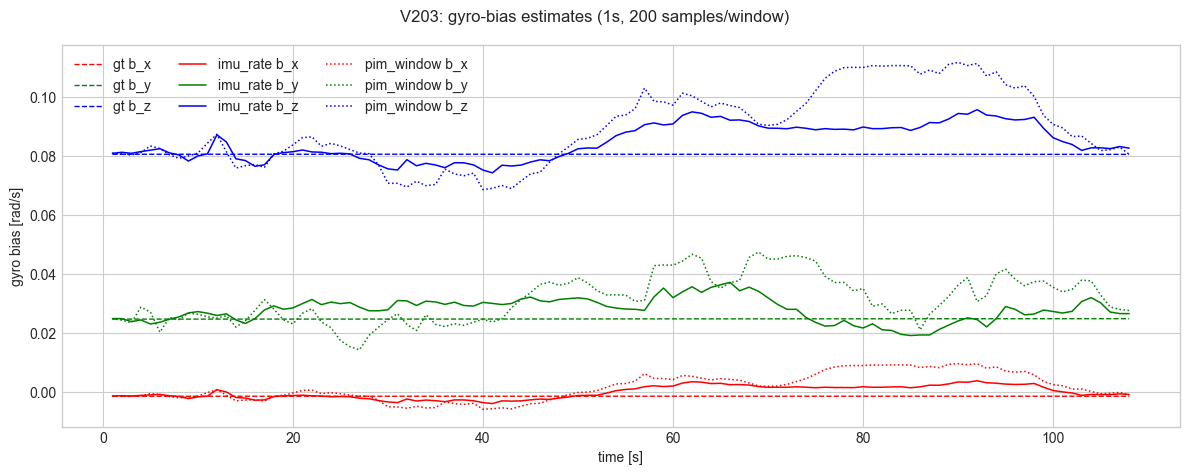

In [43]:
bias_axes = [
    ("x", "red"),
    ("y", "green"),
    ("z", "blue"),
]
method_line_styles = {
    "imu_rate": "-",
    "pim_window": ":",
}

for dataset, dataset_df in pim_data.groupby("dataset", sort=True):
    fig, axis = plt.subplots(1, 1, figsize=(12, 4.8), sharex=True)
    interval = dataset_df["interval_seconds"].iloc[0]
    samples = dataset_df["samples_per_window"].iloc[0]
    fig.suptitle(f"{dataset}: gyro-bias estimates ({interval:g}s, {samples} samples/window)")

    reference = dataset_df[dataset_df["method"] == dataset_df["method"].iloc[0]]
    for component, color in bias_axes:
        axis.plot(
            reference["timestamp"],
            reference[f"gt_gyro_bias_{component}"],
            color=color,
            linestyle="--",
            linewidth=1.0,
            label=f"gt b_{component}",
        )

    for method, method_df in dataset_df.groupby("method", sort=True):
        line_style = method_line_styles.get(method, "-")
        for component, color in bias_axes:
            axis.plot(
                method_df["timestamp"],
                method_df[f"est_gyro_bias_{component}"],
                color=color,
                linestyle=line_style,
                linewidth=1.1,
                label=f"{method} b_{component}",
            )

    axis.set_ylabel("gyro bias [rad/s]")
    axis.set_xlabel("time [s]")
    axis.legend(loc="best", ncol=3)
    fig.tight_layout()
    plt.show()
